In [3]:
# ============================================================
# CELL 1: Install Required Libraries for Colab
# ============================================================
# This installs:
# 1. Latest Hugging Face Transformers from GitHub
# 2. Chronos forecasting package for Chronos-2
#
#
# IMPORTANT:
# After this cell finishes, restart the Colab runtime once:
# Runtime -> Restart runtime
# Then continue from Cell 2.
# ============================================================

!pip install -q --upgrade pip

# Latest Transformers source is useful for TimesFM 2.5 support.
!pip install -q "git+https://github.com/huggingface/transformers.git"

# Chronos-2 and Chronos-Bolt inference package.
!pip install -q "chronos-forecasting>=2.0"

# Standard scientific and forecasting libraries.
!pip install -q accelerate safetensors sentencepiece einops
!pip install -q statsmodels scipy scikit-learn xgboost lightgbm

print("Installation completed.")
print("Please restart runtime once before running Cell 2.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chronos-forecasting 2.2.2 requires transformers<5,>=4.41, but you have transformers 5.8.0.dev0 which is incompatible.
Installation completed.
Please restart runtime once before running Cell 2.


In [4]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg

import torch

np.random.seed(42)

print("Libraries imported successfully.")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
Torch version: 2.10.0+cu128
CUDA available: True


In [5]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg

import torch

np.random.seed(42)

print("Libraries imported successfully.")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
Torch version: 2.10.0+cu128
CUDA available: True


In [6]:
# ============================================================
# CELL 3A: User Upload Dataset and Validate Required Columns
# ============================================================
# The user should upload a CSV file containing the following columns:
#
# date, pm10, pm2_5, carbon_monoxide, nitrogen_dioxide,
# sulphur_dioxide, ozone, aerosol_optical_depth, dust, uv_index
#
# Expected date format:
# DD-MM-YYYY
# Example:
# 04-08-2022
# ============================================================

from google.colab import files

print("Please upload your PM₂.₅ dataset CSV file.")
print("Required columns:")
print([
    "date",
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "aerosol_optical_depth",
    "dust",
    "uv_index"
])

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file was uploaded. Please upload a CSV dataset.")

file_name = list(uploaded.keys())[0]

if not file_name.lower().endswith(".csv"):
    raise ValueError("Please upload a CSV file only.")

df = pd.read_csv(file_name)

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

required_cols = [
    "date",
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "aerosol_optical_depth",
    "dust",
    "uv_index"
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(
        f"The uploaded dataset is missing the following required columns: {missing_cols}"
    )

print("Dataset uploaded and validated successfully.")
print("Uploaded file:", file_name)
print("Dataset shape:", df.shape)

display(df.head())

Please upload your PM₂.₅ dataset CSV file.
Required columns:
['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index']


Saving air_quality_historical.csv to air_quality_historical (1).csv
Dataset uploaded and validated successfully.
Uploaded file: air_quality_historical (1).csv
Dataset shape: (1295, 10)


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index
0,04-08-2022,63.178947,43.594737,750.105263,52.600000,60.931579,69.631579,1.243158,2.578947,0.623684
1,05-08-2022,63.750000,43.929167,918.541667,49.037500,43.504167,72.208333,0.722500,3.000000,1.008333
2,06-08-2022,107.050000,73.745833,1395.875000,81.204167,69.608333,105.291667,0.854167,4.750000,1.731250
3,07-08-2022,61.029167,42.170833,902.166667,65.804167,48.504167,64.833333,0.853333,2.500000,1.339583
4,08-08-2022,75.850000,52.733333,1179.041667,65.000000,57.987500,75.333333,0.511250,1.125000,2.027083


In [7]:
# ============================================================
# CELL 4: Parse Date and Filter Date Range
# ============================================================

df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)

df = df.dropna(subset=["date"])
df = df.sort_values("date").reset_index(drop=True)

start_date = pd.to_datetime("04-08-2022", dayfirst=True)
end_date = pd.to_datetime("18-02-2026", dayfirst=True)

df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].copy()
df = df.sort_values("date").reset_index(drop=True)

print("Filtered date range:")
print("Start:", df["date"].min())
print("End:", df["date"].max())
print("Shape after filtering:", df.shape)

display(df.head())
display(df.tail())

Filtered date range:
Start: 2022-08-04 00:00:00
End: 2026-02-18 00:00:00
Shape after filtering: (1295, 10)


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index
0,2022-08-04,63.178947,43.594737,750.105263,52.600000,60.931579,69.631579,1.243158,2.578947,0.623684
1,2022-08-05,63.750000,43.929167,918.541667,49.037500,43.504167,72.208333,0.722500,3.000000,1.008333
2,2022-08-06,107.050000,73.745833,1395.875000,81.204167,69.608333,105.291667,0.854167,4.750000,1.731250
3,2022-08-07,61.029167,42.170833,902.166667,65.804167,48.504167,64.833333,0.853333,2.500000,1.339583
4,2022-08-08,75.850000,52.733333,1179.041667,65.000000,57.987500,75.333333,0.511250,1.125000,2.027083


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index
1290,2026-02-14,73.712500,67.108333,1213.791667,28.920833,26.975000,93.750000,0.287500,11.041667,1.110417
1291,2026-02-15,75.850000,62.220833,1097.291667,25.583333,25.245833,100.416667,0.300000,25.375000,1.062500
1292,2026-02-16,106.895833,85.150000,1281.458333,45.854167,41.137500,87.375000,0.307917,40.708333,1.172917
1293,2026-02-17,98.325000,81.729167,885.666667,42.675000,36.966667,96.666667,0.396250,31.250000,1.218750
1294,2026-02-18,80.495833,71.233333,970.000000,41.812500,31.604167,80.291667,0.817917,18.458333,0.766667


In [8]:
# ============================================================
# CELL 5: Convert Variables to Numeric and Clean Missing Values
# ============================================================

pollutant_cols = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "aerosol_optical_depth",
    "dust",
    "uv_index"
]

for col in pollutant_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[pollutant_cols] = df[pollutant_cols].replace([np.inf, -np.inf], np.nan)

print("Missing values before interpolation:")
display(df.isnull().sum())

# Ensure daily sequence.
full_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
df = df.set_index("date").reindex(full_dates)
df.index.name = "date"
df = df.reset_index()

# Interpolate numerical columns.
df[pollutant_cols] = df[pollutant_cols].interpolate(method="linear")
df[pollutant_cols] = df[pollutant_cols].bfill().ffill()

print("Missing values after interpolation:")
display(df.isnull().sum())

print("Final cleaned shape:", df.shape)
display(df.head())

Missing values before interpolation:


,0
date,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
aerosol_optical_depth,0
dust,0
uv_index,0


Missing values after interpolation:


,0
date,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
aerosol_optical_depth,0
dust,0
uv_index,0


Final cleaned shape: (1295, 10)


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index
0,2022-08-04,63.178947,43.594737,750.105263,52.600000,60.931579,69.631579,1.243158,2.578947,0.623684
1,2022-08-05,63.750000,43.929167,918.541667,49.037500,43.504167,72.208333,0.722500,3.000000,1.008333
2,2022-08-06,107.050000,73.745833,1395.875000,81.204167,69.608333,105.291667,0.854167,4.750000,1.731250
3,2022-08-07,61.029167,42.170833,902.166667,65.804167,48.504167,64.833333,0.853333,2.500000,1.339583
4,2022-08-08,75.850000,52.733333,1179.041667,65.000000,57.987500,75.333333,0.511250,1.125000,2.027083


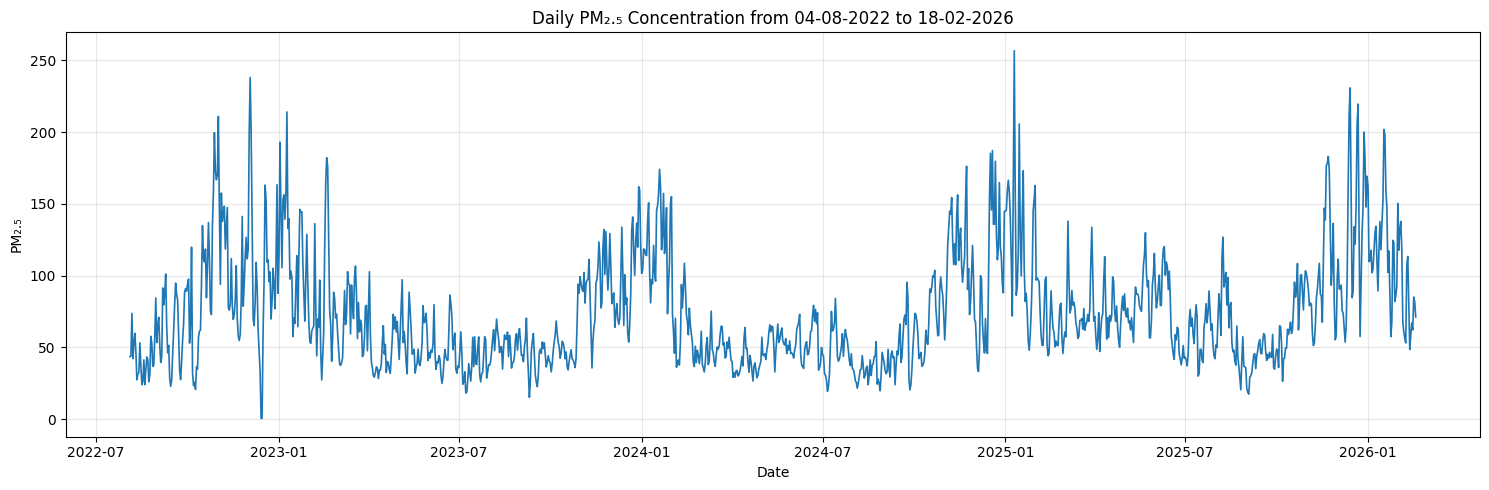

,count,mean,std,min,25%,50%,75%,max
pm10,1295.0,141.081390,103.512731,0.895833,79.089583,114.854167,164.350000,929.841667
pm2_5,1295.0,73.538291,38.274817,0.620833,45.187500,63.383333,93.772917,256.733333
carbon_monoxide,1295.0,1002.133704,662.683056,60.333333,546.791667,785.125000,1265.333333,6311.625000
nitrogen_dioxide,1295.0,42.389743,21.651176,0.000000,26.783333,36.875000,52.964583,155.783333
sulphur_dioxide,1295.0,38.202676,24.046676,0.529167,22.729167,30.545833,46.120833,229.683333
ozone,1295.0,85.288422,23.340610,21.458333,69.270833,83.666667,97.916667,166.000000
aerosol_optical_depth,1295.0,0.603134,0.300518,0.037083,0.370625,0.539167,0.767708,2.218750
dust,1295.0,107.858845,197.715990,0.000000,5.541667,23.333333,103.083333,1487.875000
uv_index,1295.0,1.283167,0.526847,0.141667,0.808333,1.247917,1.711458,2.566667


In [9]:
# ============================================================
# CELL 6: Exploratory Plot of PM2.5
# ============================================================

plt.figure(figsize=(15, 5))
plt.plot(df["date"], df["pm2_5"], linewidth=1.2)
plt.xlabel("Date")
plt.ylabel("PM₂.₅")
plt.title("Daily PM₂.₅ Concentration from 04-08-2022 to 18-02-2026")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(df[pollutant_cols].describe().T)

In [10]:
# ============================================================
# CELL 7: Train-Test Split for Multi-Step Forecasting
# ============================================================
# The foundation models forecast the full test horizon from the training context.
# First 80% = training context
# Last 20% = test horizon
# ============================================================

target_col = "pm2_5"

split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

prediction_length = len(test_df)

print("Training period:")
print(train_df["date"].min(), "to", train_df["date"].max())
print("Training length:", len(train_df))

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())
print("Testing length / prediction length:", prediction_length)

y_train = train_df[target_col].astype(float).values
y_test = test_df[target_col].astype(float).values
date_test = test_df["date"].values

Training period:
2022-08-04 00:00:00 to 2025-06-04 00:00:00
Training length: 1036

Testing period:
2025-06-05 00:00:00 to 2026-02-18 00:00:00
Testing length / prediction length: 259


In [11]:
# ============================================================
# CELL 8: Evaluation Function and Result Containers
# ============================================================

all_results = []
all_predictions = {}

def evaluate_forecast(y_true, y_pred, model_name):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1.0))
    ) * 100

    numerator = np.sum((y_pred - y_true) ** 2)
    denominator = np.sum(
        (np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2
    )

    ioa = 1 - numerator / denominator if denominator != 0 else np.nan

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2,
        "Index of Agreement": ioa
    }

def add_result(model_name, pred):
    pred = np.asarray(pred, dtype=float)
    pred = pred[:len(y_test)]

    all_predictions[model_name] = pred
    all_results.append(evaluate_forecast(y_test, pred, model_name))

    print(f"{model_name} completed.")
    display(pd.DataFrame(all_results).sort_values("RMSE").reset_index(drop=True))

print("Evaluation utilities ready.")

Evaluation utilities ready.


In [12]:
# ============================================================
# CELL 9: Baseline Forecasting Models
# ============================================================

# 1. Persistence forecast:
# Every future value = last observed PM2.5 in training.
persistence_pred = np.repeat(y_train[-1], prediction_length)
add_result("Persistence Baseline", persistence_pred)

# 2. Seasonal naive weekly forecast:
# Repeat last 7 days pattern.
last_week = y_train[-7:]

seasonal_naive_pred = np.resize(last_week, prediction_length)
add_result("Seasonal Naive Weekly", seasonal_naive_pred)

# 3. Mean baseline:
mean_pred = np.repeat(np.mean(y_train), prediction_length)
add_result("Historical Mean Baseline", mean_pred)

Persistence Baseline completed.


,Model,MAE,RMSE,MAPE (%),R2,Index of Agreement
0,Persistence Baseline,35.224067,42.740154,60.099796,-0.066452,0.275504


Seasonal Naive Weekly completed.


,Model,MAE,RMSE,MAPE (%),R2,Index of Agreement
0,Persistence Baseline,35.224067,42.740154,60.099796,-0.066452,0.275504
1,Seasonal Naive Weekly,36.962275,44.468264,61.892399,-0.154435,0.289786


Historical Mean Baseline completed.


,Model,MAE,RMSE,MAPE (%),R2,Index of Agreement
0,Persistence Baseline,35.224067,42.740154,60.099796,-0.066452,0.275504
1,Historical Mean Baseline,31.927842,42.828396,42.941425,-0.070860,0.281126
2,Seasonal Naive Weekly,36.962275,44.468264,61.892399,-0.154435,0.289786


In [13]:
# ============================================================
# CELL 15: Chronos-2 Forecasting with Covariates
# ============================================================
# Chronos-2 supports covariate-informed forecasting.
#
# For retrospective evaluation:
# - context_df contains historical PM2.5 and covariates.
# - future_df contains future covariates for the test period.
#
# In real deployment:
# future covariates must be known from weather/air-quality forecast
# or predicted separately.
# ============================================================

try:
    from chronos import Chronos2Pipeline

    device_map = "cuda" if torch.cuda.is_available() else "cpu"

    chronos2_pipeline = Chronos2Pipeline.from_pretrained(
        "amazon/chronos-2",
        device_map=device_map
    )

    chronos_context_df = train_df.copy()
    chronos_context_df = chronos_context_df.rename(
        columns={
            "date": "timestamp",
            "pm2_5": "target"
        }
    )

    chronos_context_df["id"] = "pm25_series"

    chronos_context_df = chronos_context_df[
        [
            "id",
            "timestamp",
            "target",
            "pm10",
            "carbon_monoxide",
            "nitrogen_dioxide",
            "sulphur_dioxide",
            "ozone",
            "aerosol_optical_depth",
            "dust",
            "uv_index"
        ]
    ]

    chronos_future_df = test_df.copy()
    chronos_future_df = chronos_future_df.rename(
        columns={
            "date": "timestamp"
        }
    )

    chronos_future_df["id"] = "pm25_series"

    chronos_future_df = chronos_future_df[
        [
            "id",
            "timestamp",
            "pm10",
            "carbon_monoxide",
            "nitrogen_dioxide",
            "sulphur_dioxide",
            "ozone",
            "aerosol_optical_depth",
            "dust",
            "uv_index"
        ]
    ]

    chronos2_pred_df = chronos2_pipeline.predict_df(
        chronos_context_df,
        future_df=chronos_future_df,
        prediction_length=prediction_length,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="id",
        timestamp_column="timestamp",
        target="target"
    )

    display(chronos2_pred_df.head())

    # Usually median forecast is stored in column "0.5".
    # This fallback handles possible naming differences.
    possible_median_cols = ["0.5", 0.5, "median", "mean"]

    median_col = None
    for col in possible_median_cols:
        if col in chronos2_pred_df.columns:
            median_col = col
            break

    if median_col is None:
        numeric_cols = chronos2_pred_df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) == 0:
            raise ValueError("No numeric forecast column found in Chronos-2 output.")
        median_col = numeric_cols[0]

    chronos2_pred = chronos2_pred_df[median_col].values[:prediction_length]

    add_result("Chronos-2 Covariate-Informed", chronos2_pred)

except Exception as e:
    print("Chronos-2 failed.")
    print("Possible reasons: runtime not restarted after installation, GPU/CPU memory issue, or package version conflict.")
    print(e)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,pm25_series,2025-06-05,target,99.007515,90.268669,99.007515,107.626137
1,pm25_series,2025-06-06,target,69.930435,61.881882,69.930435,77.412071
2,pm25_series,2025-06-07,target,66.400200,58.214844,66.400200,74.862343
3,pm25_series,2025-06-08,target,100.096237,87.827599,100.096237,111.378677
4,pm25_series,2025-06-09,target,104.121841,91.619797,104.121841,117.758835


Chronos-2 Covariate-Informed completed.


,Model,MAE,RMSE,MAPE (%),R2,Index of Agreement
0,Chronos-2 Covariate-Informed,8.480108,11.235891,11.066568,0.926297,0.979910
1,Persistence Baseline,35.224067,42.740154,60.099796,-0.066452,0.275504
2,Historical Mean Baseline,31.927842,42.828396,42.941425,-0.070860,0.281126
3,Seasonal Naive Weekly,36.962275,44.468264,61.892399,-0.154435,0.289786


Available Chronos models for plotting:
- Chronos-2 Covariate-Informed


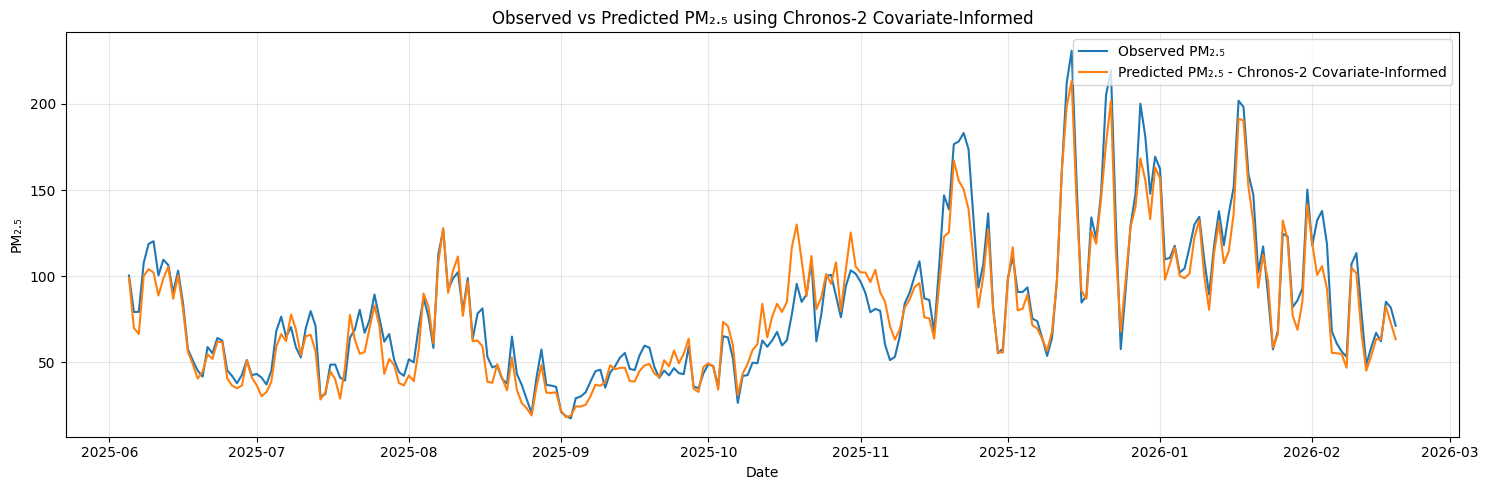

In [17]:
# ============================================================
# CELL 15A: Plot Chronos-2 Forecast after Cell 15
# ============================================================
# This cell plots the observed PM₂.₅ values against the
# Chronos-2 covariate-informed forecast generated in Cell 15.
#
# Legend is placed inside the plot at the upper-right corner.
# ============================================================

# ------------------------------------------------------------
# Step 1: Collect Chronos-2 prediction if available
# ------------------------------------------------------------

chronos_predictions = {}

for model_name, prediction_values in all_predictions.items():
    try:
        if prediction_values is not None and "Chronos-2" in model_name:
            chronos_predictions[model_name] = prediction_values
    except NameError:
        pass

print("Available Chronos models for plotting:")

if len(chronos_predictions) == 0:
    print("No Chronos-2 prediction found.")
    print("Please run Cell 15 successfully before running this cell.")
else:
    for model_name in chronos_predictions.keys():
        print("-", model_name)


# ------------------------------------------------------------
# Step 2: Generate one plot for each available Chronos model
# ------------------------------------------------------------

for model_name, prediction_values in chronos_predictions.items():

    prediction_values = np.asarray(prediction_values, dtype=float)

    n = min(
        len(date_test),
        len(y_test),
        len(prediction_values)
    )

    plt.figure(figsize=(15, 5))

    plt.plot(
        date_test[:n],
        y_test[:n],
        label="Observed PM₂.₅",
        linewidth=1.5
    )

    plt.plot(
        date_test[:n],
        prediction_values[:n],
        label=f"Predicted PM₂.₅ - {model_name}",
        linewidth=1.5
    )

    plt.xlabel("Date")
    plt.ylabel("PM₂.₅")
    plt.title(f"Observed vs Predicted PM₂.₅ using {model_name}")

    # Legend placed like your sample image: inside upper-right
    plt.legend(
        loc="upper right",
        frameon=True
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()